<img src=https://lh4.googleusercontent.com/proxy/WNtyuTbDjnnITJFxg1dlI63L0jfIMRf0CIKg75VavFd3ameUuokpEiXIZvafO0UbA3rGKkhjDZ2HFtRWcGiPIn7Syd37PqnCrQuXFNHguRRPYm__safRJi9Q width="300"/>

# **Módulo 3: Recomendación de Destinos de Viaje**

En este notebook se desarrolla un sistema de recomendación personalizado basado en los datos de interacción usuario-producto (historial de viajes de los clientes, preferencias de destino, etc.) para sugerir destinos de viaje.

**Profesor:** Juan David Ospina

**Monitor:** Andrés Mauricio Zapata

**Integrantes:** Tomás Acevedo Roldán, Santiago Cardona Franco, Jimena Hernández Castillo

**Introducción a Redes Neuronales y Algoritmos Bioinspirados** - Semestre 2026-01

**Universidad Nacional de Colombia (Facultad de Minas)**


## **Descripción del problema**
Las empresas de viajes en línea buscan mejorar la experiencia del cliente y aumentar las reservas sugiriendo destinos de viaje que se ajusten a los intereses y preferencias individuales de cada usuario. Para lograr esto, es necesario desarrollar un sistema de recomendación que analice el historial de viajes, las preferencias declaradas y el comportamiento de navegación de los clientes para generar recomendaciones personalizadas.

El objetivo de la actividad es recomendar destinos de viaje personalizados utilizando el dataset [*Travel Recommendation Dataset* de Kaggle](https://www.kaggle.com/datasets/amanmehra23/travel-recommendation-dataset/data?select=Expanded_Destinations.csv).

## **1. Importación de librerías y carga de datos**

In [30]:
import warnings
import pandas as pd
import numpy as np
import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score

In [31]:
# Configuración de visualización y semillas para reproducibilidad
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Configuración de directorios
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data' / 'modulo3'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / 'output' / 'modulo3'
MODELS_DIR = OUTPUT_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

def fijar_semillas(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.enabled = False

fijar_semillas(42)

# Carga de datos
# Carga de rutas (Paths)
path_destinations = kagglehub.dataset_download("amanmehra23/travel-recommendation-dataset", "Expanded_Destinations.csv")
path_reviews = kagglehub.dataset_download("amanmehra23/travel-recommendation-dataset", "Final_Updated_Expanded_Reviews.csv")
path_user_history = kagglehub.dataset_download("amanmehra23/travel-recommendation-dataset", "Final_Updated_Expanded_UserHistory.csv")
path_users = kagglehub.dataset_download("amanmehra23/travel-recommendation-dataset", "Final_Updated_Expanded_Users.csv")

# Carga de Datasets (DataFrames)
df_Destinations = pd.read_csv(path_destinations)
df_Reviews = pd.read_csv(path_reviews)
df_UserHistory = pd.read_csv(path_user_history)
df_Users = pd.read_csv(path_users)

# Impresión de tamaños para confirmación
print(f"{'Dataset':<20} | {'Filas':<10} | {'Columnas':<10}")
print("-" * 45)
print(f"{'Destinations':<20} | {df_Destinations.shape[0]:<10,} | {df_Destinations.shape[1]:<10,}")
print(f"{'Reviews':<20} | {df_Reviews.shape[0]:<10,} | {df_Reviews.shape[1]:<10,}")
print(f"{'UserHistory':<20} | {df_UserHistory.shape[0]:<10,} | {df_UserHistory.shape[1]:<10,}")
print(f"{'Users':<20} | {df_Users.shape[0]:<10,} | {df_Users.shape[1]:<10,}")

Dataset              | Filas      | Columnas  
---------------------------------------------
Destinations         | 1,000      | 6         
Reviews              | 999        | 5         
UserHistory          | 999        | 5         
Users                | 999        | 7         


In [32]:
# Inspección de los datasets
datasets = {
    "Destinos": df_Destinations,
    "Reviews": df_Reviews,
    "Historial de Usuario": df_UserHistory,
    "Usuarios": df_Users
}

for nombre, df in datasets.items():
    print(f"=== Base de Datos: {nombre} ===")
    print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
    print("\nColumnas y tipos de datos:")
    print(df.dtypes)
    print("-" * 50)

=== Base de Datos: Destinos ===
Dimensiones: 1000 filas, 6 columnas

Columnas y tipos de datos:
DestinationID        int64
Name                   str
State                  str
Type                   str
Popularity         float64
BestTimeToVisit        str
dtype: object
--------------------------------------------------
=== Base de Datos: Reviews ===
Dimensiones: 999 filas, 5 columnas

Columnas y tipos de datos:
ReviewID         int64
DestinationID    int64
UserID           int64
Rating           int64
ReviewText         str
dtype: object
--------------------------------------------------
=== Base de Datos: Historial de Usuario ===
Dimensiones: 999 filas, 5 columnas

Columnas y tipos de datos:
HistoryID           int64
UserID              int64
DestinationID       int64
VisitDate             str
ExperienceRating    int64
dtype: object
--------------------------------------------------
=== Base de Datos: Usuarios ===
Dimensiones: 999 filas, 7 columnas

Columnas y tipos de datos:
UserID

## **2. Preprocesamiento y limpieza de los datos**

In [33]:
# Eliminamos duplicados de destinos si existen
df_Destinations = df_Destinations.drop_duplicates(subset=['DestinationID'])

# Columnas irrelevantes: 'ReviewID' (es solo un autoincremental) y 'ReviewText'
df_Reviews = df_Reviews.drop(columns=['ReviewID', 'ReviewText'], errors='ignore')

# Verificación y eliminación de nulos en filas críticas
df_Reviews = df_Reviews.dropna(subset=['UserID', 'DestinationID', 'Rating'])

# Columnas irrelevantes: 'HistoryID' (ID interno) y 'VisitDate' (La fecha exacta no la usaremos en el recomendador estático)
df_UserHistory = df_UserHistory.drop(columns=['HistoryID', 'VisitDate'], errors='ignore')

# Cambiamos el nombre de 'ExperienceRating' a 'Rating' para que coincida con las Reviews
df_UserHistory = df_UserHistory.rename(columns={'ExperienceRating': 'Rating'})

# Verificación de nulos
df_UserHistory = df_UserHistory.dropna(subset=['UserID', 'DestinationID', 'Rating'])

# Columnas irrelevantes: 'Name' e 'Email' (Por motivos éticos y de privacidad de datos GDPR/Habeas Data, y porque no aportan al modelo)
df_Users = df_Users.drop(columns=['Name', 'Email'], errors='ignore')

# Tratamiento de nulos en preferencias: Si no tiene, le asignamos 'General' para no perder el usuario
df_Users['Preferences'] = df_Users['Preferences'].fillna('General')

# Rellenar nulos en número de acompañantes con 0 (asumiendo que viaja solo)
df_Users['NumberOfAdults'] = df_Users['NumberOfAdults'].fillna(1)
df_Users['NumberOfChildren'] = df_Users['NumberOfChildren'].fillna(0)

# Mostrar cómo quedaron los DataFrames limpios
print(f"Destinos limpios: {df_Destinations.shape} -> Columnas: {list(df_Destinations.columns)}")
print(f"Reviews limpias: {df_Reviews.shape} -> Columnas: {list(df_Reviews.columns)}")
print(f"Historial limpio: {df_UserHistory.shape} -> Columnas: {list(df_UserHistory.columns)}")
print(f"Usuarios limpios: {df_Users.shape} -> Columnas: {list(df_Users.columns)}")

Destinos limpios: (1000, 6) -> Columnas: ['DestinationID', 'Name', 'State', 'Type', 'Popularity', 'BestTimeToVisit']
Reviews limpias: (999, 3) -> Columnas: ['DestinationID', 'UserID', 'Rating']
Historial limpio: (999, 3) -> Columnas: ['UserID', 'DestinationID', 'Rating']
Usuarios limpios: (999, 5) -> Columnas: ['UserID', 'Preferences', 'Gender', 'NumberOfAdults', 'NumberOfChildren']


## **3. Análisis descriptivo**

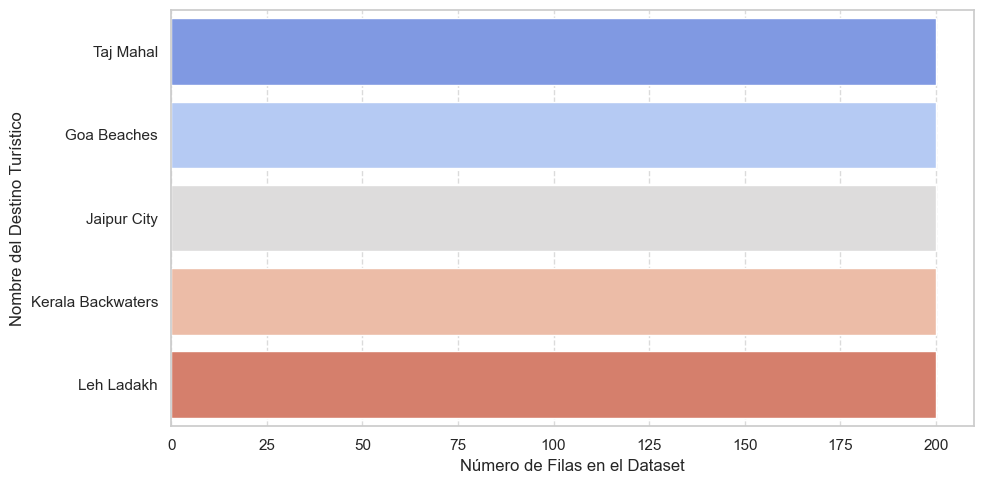

Número total de filas en df_Destinations: 1000
Cantidad de nombres de destinos únicos reales: 5
Frecuencia de aparición por cada lugar:
Name
Taj Mahal            200
Goa Beaches          200
Jaipur City          200
Kerala Backwaters    200
Leh Ladakh           200
Name: count, dtype: int64


In [34]:
# Variedad en el catálogo de destinos
plt.figure(figsize=(10, 5))
destino_counts = df_Destinations['Name'].value_counts()
sns.barplot(x=destino_counts.values, y=destino_counts.index, hue=destino_counts.index, palette='coolwarm', legend=False)
plt.xlabel('Número de Filas en el Dataset')
plt.ylabel('Nombre del Destino Turístico')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_frecuencia_destinos.png')
plt.show()

print(f"Número total de filas en df_Destinations: {len(df_Destinations)}")
print(f"Cantidad de nombres de destinos únicos reales: {df_Destinations['Name'].nunique()}")
print(f"Frecuencia de aparición por cada lugar:\n{df_Destinations['Name'].value_counts()}")

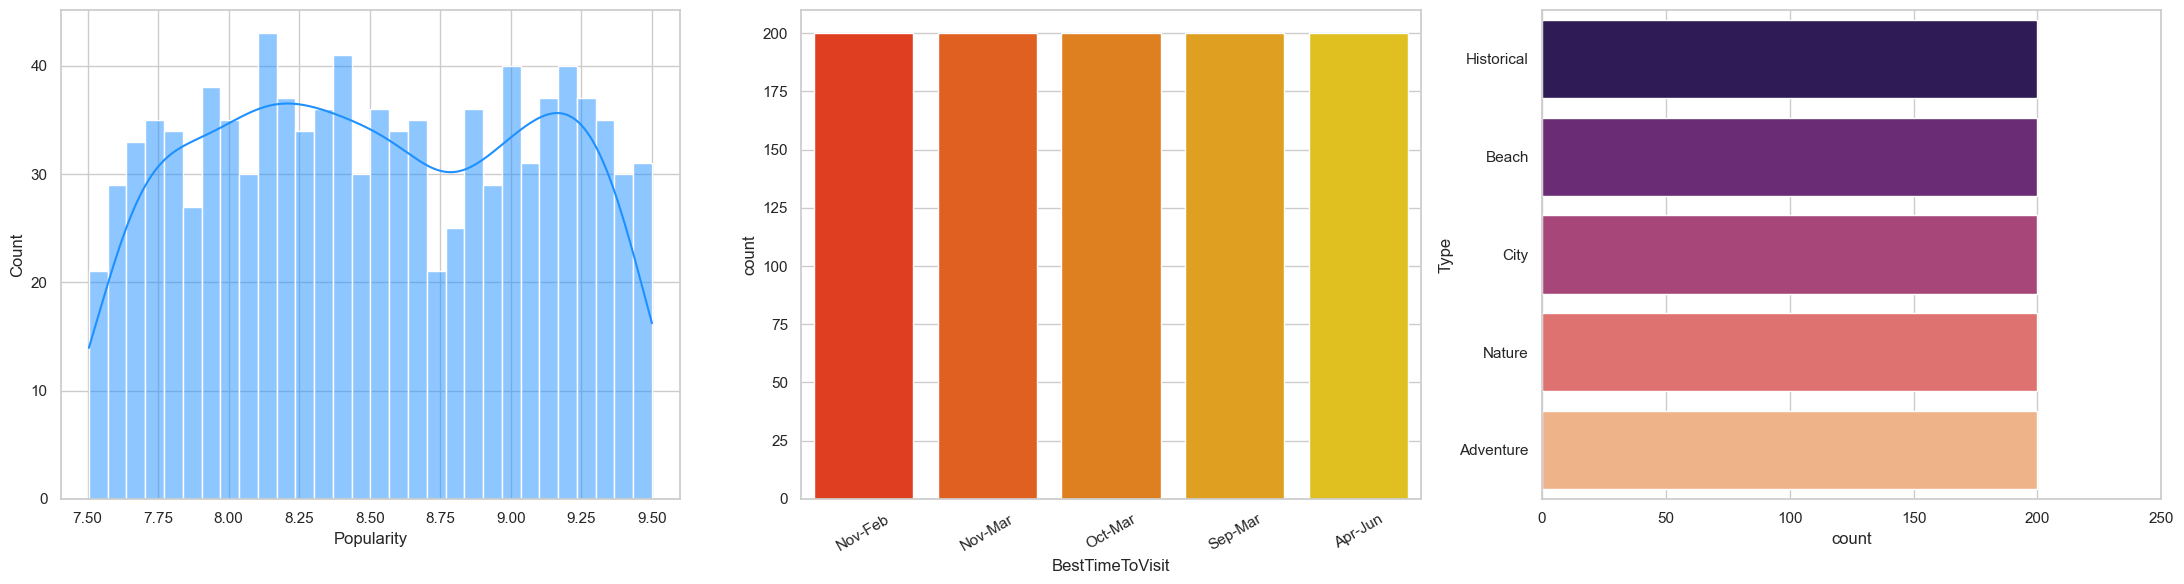

Total de categorías únicas de destinos (Types): 5
Listado de categorías identificadas: <ArrowStringArray>
['Historical', 'Beach', 'City', 'Nature', 'Adventure']
Length: 5, dtype: str
Rango de Popularidad: Mínima: 7.50 | Máxima: 9.50
Temporada más común para viajar: 'Nov-Feb'


In [35]:
# Analisis exploratorio de destinos
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.histplot(data=df_Destinations, x='Popularity', ax=axes[0], kde=True, color='dodgerblue', bins=30)
sns.countplot(data=df_Destinations, x='BestTimeToVisit', ax=axes[1], order=df_Destinations['BestTimeToVisit'].value_counts().index, hue='BestTimeToVisit', palette='autumn', legend=False)
axes[1].tick_params(axis='x', rotation=30)
sns.countplot(data=df_Destinations, y='Type', ax=axes[2], order=df_Destinations['Type'].value_counts().index, hue='Type', palette='magma', legend=False)
axes[2].set_xlim(0, 250)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_analisis_destinos.png')
plt.show()

print(f"Total de categorías únicas de destinos (Types): {df_Destinations['Type'].nunique()}")
print(f"Listado de categorías identificadas: {df_Destinations['Type'].unique()}")
print(f"Rango de Popularidad: Mínima: {df_Destinations['Popularity'].min():.2f} | Máxima: {df_Destinations['Popularity'].max():.2f}")
print(f"Temporada más común para viajar: '{df_Destinations['BestTimeToVisit'].value_counts().idxmax()}'")


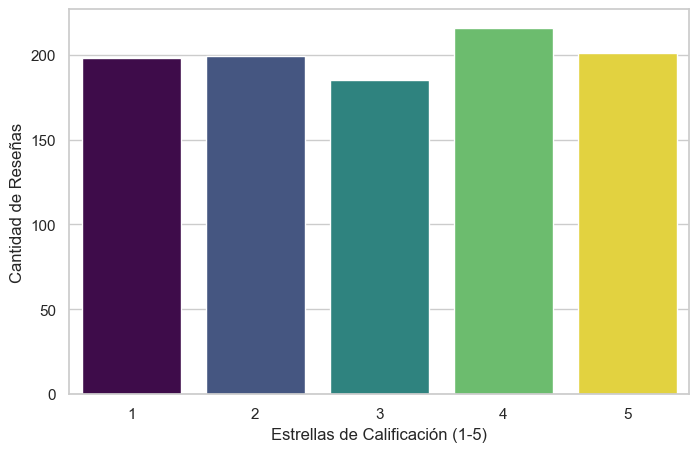

Total de calificaciones registradas vía Reviews: 999
Rating promedio en Reviews públicas: 3.02 / 5.0


In [36]:
# Analisis exploratorio - Reviews
plt.figure(figsize=(8, 5))
sns.countplot(data=df_Reviews, x='Rating', hue='Rating', palette='viridis', legend=False)
plt.xlabel('Estrellas de Calificación (1-5)')
plt.ylabel('Cantidad de Reseñas')
plt.savefig(OUTPUT_DIR / '03_distribucion_reviews.png')
plt.show()

print(f"Total de calificaciones registradas vía Reviews: {len(df_Reviews)}")
print(f"Rating promedio en Reviews públicas: {df_Reviews['Rating'].mean():.2f} / 5.0")

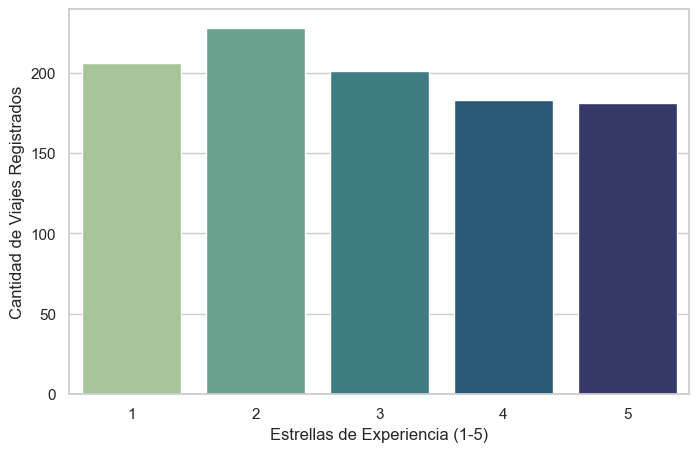

Total de registros operativos en el Historial: 999
Rating promedio del servicio/experiencia en viajes: 2.90 / 5.0


In [37]:
# Analisis exploratorio - Historial de Usuario
plt.figure(figsize=(8, 5))
sns.countplot(data=df_UserHistory, x='Rating', hue='Rating', palette='crest', legend=False)
plt.xlabel('Estrellas de Experiencia (1-5)')
plt.ylabel('Cantidad de Viajes Registrados')
plt.savefig(OUTPUT_DIR / '04_historial_usuario.png')
plt.show()

print(f"Total de registros operativos en el Historial: {len(df_UserHistory)}")
print(f"Rating promedio del servicio/experiencia en viajes: {df_UserHistory['Rating'].mean():.2f} / 5.0")

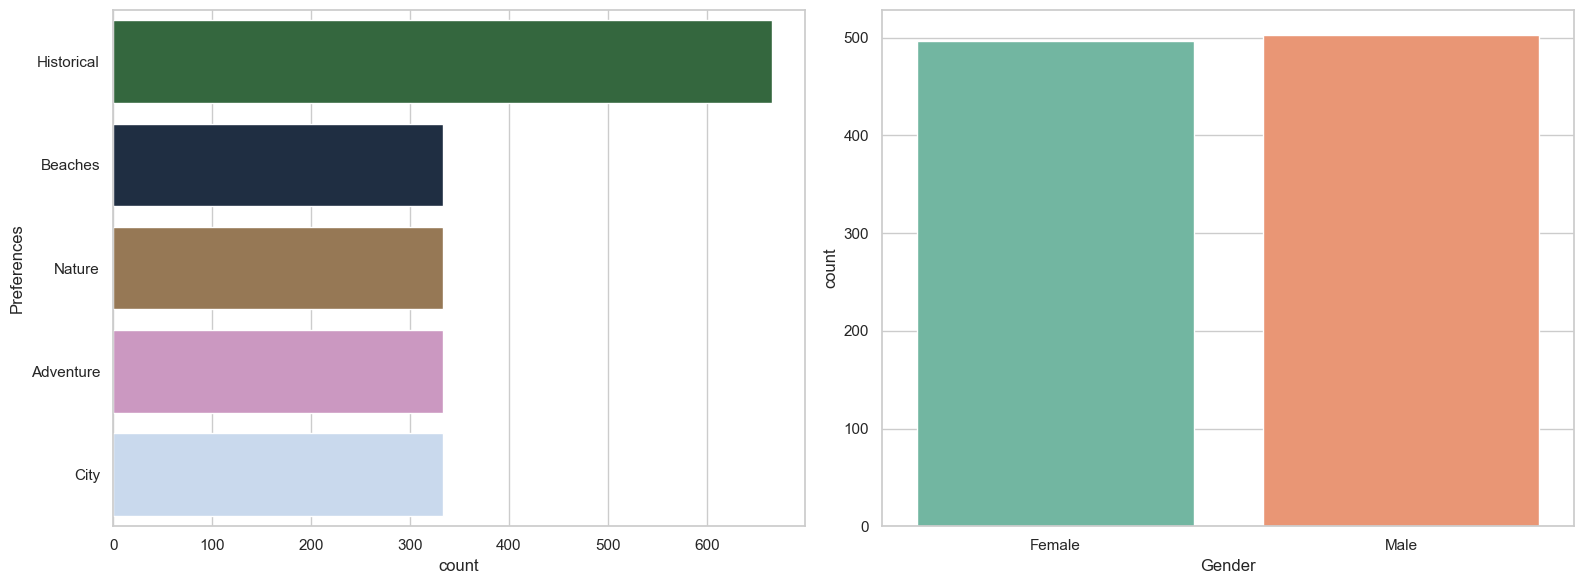

Promedio de Adultos por cuenta de usuario: 1.50
Promedio de Niños por cuenta de usuario: 0.98
Distribución porcentual del mercado por Género:
Gender
Male      50.35035
Female    49.64965
Name: proportion, dtype: float64


In [38]:
# Analisis exploratorio - Usuarios
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
all_prefs_series = df_Users['Preferences'].str.split(', ').explode()
sns.countplot(y=all_prefs_series, ax=axes[0], order=all_prefs_series.value_counts().index, hue=all_prefs_series, palette='cubehelix', legend=False)
sns.countplot(data=df_Users, x='Gender', ax=axes[1], hue='Gender', palette='Set2', legend=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_analisis_usuarios.png')
plt.show()

print(f"Promedio de Adultos por cuenta de usuario: {df_Users['NumberOfAdults'].mean():.2f}")
print(f"Promedio de Niños por cuenta de usuario: {df_Users['NumberOfChildren'].mean():.2f}")
print(f"Distribución porcentual del mercado por Género:")
print(df_Users['Gender'].value_counts(normalize=True) * 100)

## **4. Preparación de los datos para entrenar el modelo**

In [39]:
# Unificar las fuentes de interacción (Reviews + Historial Operativo)
df_rev_temp = df_Reviews[['UserID', 'DestinationID', 'Rating']].copy()
df_hist_temp = df_UserHistory[['UserID', 'DestinationID', 'Rating']].copy()

df_master_interactions = pd.concat([df_rev_temp, df_hist_temp], ignore_index=True)

# Resolver redundancia: Promediar calificaciones si un usuario repite destino
df_master_interactions = df_master_interactions.groupby(['UserID', 'DestinationID'], as_index=False)['Rating'].mean()
print(f"Matriz Maestra consolidada. Total de interacciones únicas: {len(df_master_interactions)}")

# CREACIÓN DE ÍNDICES CONTIGUOS PARA PYTORCH (Embeddings Mappings)
df_master_interactions['user_idx'] = df_master_interactions['UserID'].astype('category').cat.codes
df_master_interactions['dest_idx'] = df_master_interactions['DestinationID'].astype('category').cat.codes

# Creamos los diccionarios de traducción para producción
user_to_idx = dict(zip(df_master_interactions['UserID'], df_master_interactions['user_idx']))
dest_to_idx = dict(zip(df_master_interactions['DestinationID'], df_master_interactions['dest_idx']))
idx_to_dest = {v: k for k, v in dest_to_idx.items()}

num_users = df_master_interactions['user_idx'].nunique()
num_destinations = df_master_interactions['dest_idx'].nunique()

print(f"Mapeo completado de forma segura:")
print(f"   • {num_users} usuarios mapeados internamente en un rango de [0 a {num_users-1}]")
print(f"   • {num_destinations} destinos mapeados internamente en un rango de [0 a {num_destinations-1}]")

# ACOPLE DE CARACTERÍSTICAS CONTEXTUALES (Modelo Híbrido)
df_Users['Total_Travelers'] = df_Users['NumberOfAdults'] + df_Users['NumberOfChildren']

# Convertimos Gender a binario (Male: 1, Female: 0)
df_Users['Gender_Bin'] = df_Users['Gender'].map({'Male': 1, 'Female': 0}).fillna(0)

# Multi-Hot Encoding de Preferencias
df_users_encoded = df_Users['Preferences'].str.get_dummies(sep=', ')

# Ahora sí, consolidamos el perfil numérico del usuario sin errores
df_users_features = pd.concat([df_Users[['UserID', 'Total_Travelers', 'Gender_Bin']], df_users_encoded], axis=1)

# Unimos las interacciones con el contexto del usuario
df_final_dataset = pd.merge(df_master_interactions, df_users_features, on='UserID', how='left')

# Definimos exactamente cuáles columnas serán los metadatos de contexto (features)
feature_cols = [col for col in df_final_dataset.columns if col not in ['UserID', 'DestinationID', 'Rating', 'user_idx', 'dest_idx']]
print(f"Variables de contexto que ingresarán a la red: {feature_cols}")

# DIVISIÓN EN ENTRENAMIENTO (80%) Y PRUEBA (20%)
train_df, test_df = train_test_split(df_final_dataset, test_size=0.2, random_state=42)

# Guardamos el archivo con index=False para evitar columnas fantasma de índices
df_final_dataset.to_csv(f'{DATA_DIR}/final_preprocessed_travel_dataset.csv', index=False)
print(f"\nDataset final estructurado con éxito:")
print(f"   • Tamaño del Set de Entrenamiento (80%): {train_df.shape[0]} interacciones.")
print(f"   • Tamaño del Set de Prueba (20%): {test_df.shape[0]} interacciones.")
print(f"Archivo 'final_preprocessed_travel_dataset.csv' guardado en {DATA_DIR}.")

Matriz Maestra consolidada. Total de interacciones únicas: 1998
Mapeo completado de forma segura:
   • 858 usuarios mapeados internamente en un rango de [0 a 857]
   • 866 destinos mapeados internamente en un rango de [0 a 865]
Variables de contexto que ingresarán a la red: ['Total_Travelers', 'Gender_Bin', 'Adventure', 'Beaches', 'City', 'Historical', 'Nature']

Dataset final estructurado con éxito:
   • Tamaño del Set de Entrenamiento (80%): 1598 interacciones.
   • Tamaño del Set de Prueba (20%): 400 interacciones.
Archivo 'final_preprocessed_travel_dataset.csv' guardado en c:\Users\USUARIO\Documents\Clases\2026_1\RNA y Algo. Bioinsp\RNAAB_T03\data\modulo3.


### Creación de componentes nativos de PyTorch

In [40]:
# Definición de la clase Dataset
class TravelDataset(Dataset):
    def __init__(self, df, feature_columns):
        # Convertimos los índices de usuarios y destinos a tensores de enteros largos (long)
        self.user_indices = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.dest_indices = torch.tensor(df['dest_idx'].values, dtype=torch.long)

        # Convertimos las características de contexto a tensores de punto flotante (float32)
        self.context_features = torch.tensor(df[feature_columns].values, dtype=torch.float32)

        # Convertimos la variable objetivo (Rating) a tensor flotante
        self.ratings = torch.tensor(df['Rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        # Retorna una tupla con todos los componentes que necesita la red por cada fila
        return self.user_indices[idx], self.dest_indices[idx], self.context_features[idx], self.ratings[idx]

# Instanciar los objetos Dataset con el 80% y 20% correspondientes
train_dataset = TravelDataset(train_df, feature_cols)
test_dataset = TravelDataset(test_df, feature_cols)

# Crear los DataLoaders (Alimentadores por lotes de tamaño 64)
# Mezclamos (shuffle=True) el entrenamiento para que el modelo no se vuelva dependiente del orden de los datos
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Componentes de PyTorch creados con éxito:")
print(f"   • {len(train_loader)} lotes (batches) preparados para el Entrenamiento.")
print(f"   • {len(test_loader)} lotes (batches) preparados para la Prueba.")

Componentes de PyTorch creados con éxito:
   • 25 lotes (batches) preparados para el Entrenamiento.
   • 7 lotes (batches) preparados para la Prueba.


### Función para evaluar los modelos

In [41]:
# Asegurar persistencia del hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Inicializar la lista global de experimentos
historial_experimentos = []

def registrar_experimento(nombre_modelo, train_losses, test_losses, test_loader, modelo_entrenado, umbral=3.0):
    """
    Evalúa el modelo entrenado y registra las métricas continuas y binarias en el historial.
    """
    modelo_entrenado.eval()
    preds_lista, reales_lista = [], []

    with torch.no_grad():
        for users, dests, features, ratings in test_loader:
            users, dests, features = users.to(device), dests.to(device), features.to(device)
            outputs = modelo_entrenado(users, dests, features)
            preds_lista.extend(outputs.cpu().numpy())
            reales_lista.extend(ratings.numpy())

    preds_lista = np.array(preds_lista)
    reales_lista = np.array(reales_lista)

    # Cálculos continuos
    mae = mean_absolute_error(reales_lista, preds_lista)
    rmse = np.sqrt(mean_squared_error(reales_lista, preds_lista))

    # Cálculos binarios
    reales_bin = (reales_lista >= umbral).astype(int)
    preds_bin = (preds_lista >= umbral).astype(int)

    precision = precision_score(reales_bin, preds_bin, zero_division=0)
    recall = recall_score(reales_bin, preds_bin, zero_division=0)
    f1 = f1_score(reales_bin, preds_bin, zero_division=0)

    # Guardar en la estructura global
    resultado = {
        "Arquitectura": nombre_modelo,
        "Min Test MSE": round(float(np.min(test_losses)), 4),
        "MAE": round(float(mae), 4),
        "RMSE": round(float(rmse), 4),
        "Precisión (binaria)": round(float(precision), 4),
        "Recall (binario)": round(float(recall), 4),
        "F1 Score (binario)": round(float(f1), 4)
    }

    historial_experimentos.append(resultado)
    print(f" Experimento '{nombre_modelo}' guardado con éxito.")
    return pd.DataFrame(historial_experimentos)

## **5. Modelo 1: Arquitectura base**

In [42]:
# Definición de la clase de la Red Neuronal Híbrida con Sigmoide
class HybridNeuralCF(nn.Module):
    def __init__(self, num_users, num_items, num_features, embedding_dim=16):
        super(HybridNeuralCF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        input_dim = (embedding_dim * 2) + num_features
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)
        )

    def forward(self, user_indices, item_indices, context_features):
        user_emb = self.user_embedding(user_indices)
        item_emb = self.item_embedding(item_indices)
        x = torch.cat([user_emb, item_emb, context_features], dim=1)
        return torch.sigmoid(self.mlp(x).squeeze()) * 5.0

# Resetear historial para la nueva corrida limpia
historial_experimentos = []

# Inicializar Modelo 1
num_features = len(feature_cols)
model = HybridNeuralCF(num_users, num_destinations, num_features, embedding_dim=16).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

# Bucle de entrenamiento con prints por Época
epochs = 20
train_losses, test_losses = [], []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for users, dests, features, ratings in train_loader:
        users, dests, features, ratings = users.to(device), dests.to(device), features.to(device), ratings.to(device)
        optimizer.zero_grad()
        predictions = model(users, dests, features)
        loss = criterion(predictions, ratings)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * users.size(0)
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for users, dests, features, ratings in test_loader:
            users, dests, features, ratings = users.to(device), dests.to(device), features.to(device), ratings.to(device)
            predictions = model(users, dests, features)
            loss = criterion(predictions, ratings)
            running_test_loss += loss.item() * users.size(0)
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)

    # Imprimir el progreso en vivo de cada época
    print(f"Época [{epoch+1:02d}/{epochs}] | Train MSE Loss: {epoch_train_loss:.4f} | Test MSE Loss: {epoch_test_loss:.4f}")

print("\nRegistrando resultados del Experimento 1...")
df_benchmarking = registrar_experimento("Base (16 Emb, 64->32 MLP)", train_losses, test_losses, test_loader, model)
display(df_benchmarking)

Época [01/20] | Train MSE Loss: 2.0485 | Test MSE Loss: 2.0996
Época [02/20] | Train MSE Loss: 1.9233 | Test MSE Loss: 2.1145
Época [03/20] | Train MSE Loss: 1.8594 | Test MSE Loss: 2.2016
Época [04/20] | Train MSE Loss: 1.6816 | Test MSE Loss: 2.3760
Época [05/20] | Train MSE Loss: 1.5345 | Test MSE Loss: 2.5433
Época [06/20] | Train MSE Loss: 1.3544 | Test MSE Loss: 2.6350
Época [07/20] | Train MSE Loss: 1.1615 | Test MSE Loss: 2.9321
Época [08/20] | Train MSE Loss: 0.9965 | Test MSE Loss: 2.9812
Época [09/20] | Train MSE Loss: 0.8192 | Test MSE Loss: 3.0240
Época [10/20] | Train MSE Loss: 0.6863 | Test MSE Loss: 3.3034
Época [11/20] | Train MSE Loss: 0.6186 | Test MSE Loss: 3.2156
Época [12/20] | Train MSE Loss: 0.5146 | Test MSE Loss: 3.2366
Época [13/20] | Train MSE Loss: 0.4665 | Test MSE Loss: 3.3998
Época [14/20] | Train MSE Loss: 0.3898 | Test MSE Loss: 3.3631
Época [15/20] | Train MSE Loss: 0.3496 | Test MSE Loss: 3.2082
Época [16/20] | Train MSE Loss: 0.3546 | Test MSE Loss:

,Arquitectura,Min Test MSE,MAE,RMSE,Precisión (binaria),Recall (binario),F1 Score (binario)
0,"Base (16 Emb, 64->32 MLP)",2.0996,1.5351,1.8466,0.5549,0.4174,0.4764


## **6. Modelo 2: Arquitectura profunda**

In [43]:
class HybridNeuralCF_Deep(nn.Module):
    def __init__(self, num_users, num_items, num_features, embedding_dim=32):
        super(HybridNeuralCF_Deep, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        input_dim = (embedding_dim * 2) + num_features
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)
        )

    def forward(self, user_indices, item_indices, context_features):
        user_emb = self.user_embedding(user_indices)
        item_emb = self.item_embedding(item_indices)
        x = torch.cat([user_emb, item_emb, context_features], dim=1)
        return torch.sigmoid(self.mlp(x).squeeze()) * 5.0

model_deep = HybridNeuralCF_Deep(num_users, num_destinations, num_features, embedding_dim=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_deep.parameters(), lr=0.003, weight_decay=1e-5)

train_losses_deep, test_losses_deep = [], []
for epoch in range(epochs):
    model_deep.train()
    running_train_loss = 0.0
    for users, dests, features, ratings in train_loader:
        users, dests, features, ratings = users.to(device), dests.to(device), features.to(device), ratings.to(device)
        optimizer.zero_grad()
        predictions = model_deep(users, dests, features)
        loss = criterion(predictions, ratings)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * users.size(0)
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses_deep.append(epoch_train_loss)

    model_deep.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for users, dests, features, ratings in test_loader:
            users, dests, features, ratings = users.to(device), dests.to(device), features.to(device), ratings.to(device)
            predictions = model_deep(users, dests, features)
            loss = criterion(predictions, ratings)
            running_test_loss += loss.item() * users.size(0)
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses_deep.append(epoch_test_loss)

    print(f"Época [{epoch+1:02d}/{epochs}] | Train MSE Loss: {epoch_train_loss:.4f} | Test MSE Loss: {epoch_test_loss:.4f}")

print("\nRegistrando resultados del Experimento 2...")
df_benchmarking = registrar_experimento("Profundo (32 Emb, 128->64->32 MLP)", train_losses_deep, test_losses_deep, test_loader, model_deep)
display(df_benchmarking)

Época [01/20] | Train MSE Loss: 1.9743 | Test MSE Loss: 2.1022
Época [02/20] | Train MSE Loss: 1.9179 | Test MSE Loss: 2.1559
Época [03/20] | Train MSE Loss: 1.7868 | Test MSE Loss: 2.3144
Época [04/20] | Train MSE Loss: 1.5490 | Test MSE Loss: 2.5924
Época [05/20] | Train MSE Loss: 1.2931 | Test MSE Loss: 2.6823
Época [06/20] | Train MSE Loss: 0.9928 | Test MSE Loss: 2.9661
Época [07/20] | Train MSE Loss: 0.8526 | Test MSE Loss: 2.8974
Época [08/20] | Train MSE Loss: 0.7002 | Test MSE Loss: 3.0265
Época [09/20] | Train MSE Loss: 0.5607 | Test MSE Loss: 3.0863
Época [10/20] | Train MSE Loss: 0.4807 | Test MSE Loss: 3.2484
Época [11/20] | Train MSE Loss: 0.4192 | Test MSE Loss: 3.0210
Época [12/20] | Train MSE Loss: 0.3901 | Test MSE Loss: 3.1930
Época [13/20] | Train MSE Loss: 0.3491 | Test MSE Loss: 3.1135
Época [14/20] | Train MSE Loss: 0.3162 | Test MSE Loss: 3.0815
Época [15/20] | Train MSE Loss: 0.2869 | Test MSE Loss: 3.0906
Época [16/20] | Train MSE Loss: 0.2762 | Test MSE Loss:

,Arquitectura,Min Test MSE,MAE,RMSE,Precisión (binaria),Recall (binario),F1 Score (binario)
0,"Base (16 Emb, 64->32 MLP)",2.0996,1.5351,1.8466,0.5549,0.4174,0.4764
1,"Profundo (32 Emb, 128->64->32 MLP)",2.1022,1.4654,1.7394,0.5632,0.4652,0.5095


## **7. Modelo 3: Arquitectura regularizada**

In [44]:
class HybridNeuralCF_Regularized(nn.Module):
    def __init__(self, num_users, num_items, num_features, embedding_dim=16):
        super(HybridNeuralCF_Regularized, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        input_dim = (embedding_dim * 2) + num_features
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(16, 1)
        )

    def forward(self, user_indices, item_indices, context_features):
        user_emb = self.user_embedding(user_indices)
        item_emb = self.item_embedding(item_indices)
        x = torch.cat([user_emb, item_emb, context_features], dim=1)
        return torch.sigmoid(self.mlp(x).squeeze()) * 5.0

model_reg = HybridNeuralCF_Regularized(num_users, num_destinations, num_features, embedding_dim=16).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_reg.parameters(), lr=0.005, weight_decay=1e-4)

train_losses_reg, test_losses_reg = [], []
for epoch in range(epochs):
    model_reg.train()
    running_train_loss = 0.0
    for users, dests, features, ratings in train_loader:
        users, dests, features, ratings = users.to(device), dests.to(device), features.to(device), ratings.to(device)
        optimizer.zero_grad()
        predictions = model_reg(users, dests, features)
        loss = criterion(predictions, ratings)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * users.size(0)
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses_reg.append(epoch_train_loss)

    model_reg.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for users, dests, features, ratings in test_loader:
            users, dests, features, ratings = users.to(device), dests.to(device), features.to(device), ratings.to(device)
            predictions = model_reg(users, dests, features)
            loss = criterion(predictions, ratings)
            running_test_loss += loss.item() * users.size(0)
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses_reg.append(epoch_test_loss)

    print(f"Época [{epoch+1:02d}/{epochs}] | Train MSE Loss: {epoch_train_loss:.4f} | Test MSE Loss: {epoch_test_loss:.4f}")

print("\nRegistrando resultados del Experimento 3...")
df_benchmarking = registrar_experimento("Regularizado (16 Emb, 32->16 MLP, Drop 0.4)", train_losses_reg, test_losses_reg, test_loader, model_reg)
display(df_benchmarking)

Época [01/20] | Train MSE Loss: 2.0394 | Test MSE Loss: 2.0708
Época [02/20] | Train MSE Loss: 1.9747 | Test MSE Loss: 2.0640
Época [03/20] | Train MSE Loss: 1.9486 | Test MSE Loss: 2.0740
Época [04/20] | Train MSE Loss: 1.8916 | Test MSE Loss: 2.0917
Época [05/20] | Train MSE Loss: 1.8601 | Test MSE Loss: 2.1150
Época [06/20] | Train MSE Loss: 1.7794 | Test MSE Loss: 2.1555
Época [07/20] | Train MSE Loss: 1.6327 | Test MSE Loss: 2.2550
Época [08/20] | Train MSE Loss: 1.4621 | Test MSE Loss: 2.3866
Época [09/20] | Train MSE Loss: 1.2942 | Test MSE Loss: 2.4814
Época [10/20] | Train MSE Loss: 1.1384 | Test MSE Loss: 2.6387
Época [11/20] | Train MSE Loss: 1.0409 | Test MSE Loss: 2.8045
Época [12/20] | Train MSE Loss: 0.9105 | Test MSE Loss: 2.9526
Época [13/20] | Train MSE Loss: 0.8649 | Test MSE Loss: 2.9133
Época [14/20] | Train MSE Loss: 0.7201 | Test MSE Loss: 3.0132
Época [15/20] | Train MSE Loss: 0.6849 | Test MSE Loss: 2.9976
Época [16/20] | Train MSE Loss: 0.6135 | Test MSE Loss:

,Arquitectura,Min Test MSE,MAE,RMSE,Precisión (binaria),Recall (binario),F1 Score (binario)
0,"Base (16 Emb, 64->32 MLP)",2.0996,1.5351,1.8466,0.5549,0.4174,0.4764
1,"Profundo (32 Emb, 128->64->32 MLP)",2.1022,1.4654,1.7394,0.5632,0.4652,0.5095
2,"Regularizado (16 Emb, 32->16 MLP, Drop 0.4)",2.0640,1.4629,1.7757,0.5847,0.4652,0.5182


## **8. Productivización del modelo**

In [45]:
# 1. Definir la ruta del archivo de salida
ruta_exportacion = f"{MODELS_DIR}/modelo_recomendacion_viajes.pt"

# 2. Crear un diccionario con todos los artefactos necesarios
artefactos_produccion = {
    # Guardamos los pesos entrenados del modelo regularizado
    'model_state_dict': model_reg.state_dict(),

    # Guardamos las dimensiones estructurales de la red
    'num_users': num_users,
    'num_destinations': num_destinations,
    'num_features': num_features,

    # Guardamos los diccionarios de traducción (Mapeos de índices)
    'user_to_idx': user_to_idx,
    'dest_to_idx': dest_to_idx,
    'idx_to_dest': idx_to_dest,

    # Guardamos la lista exacta de las variables de contexto utilizadas
    'feature_cols': feature_cols
}

# 3. Guardar en disco de forma segura
torch.save(artefactos_produccion, ruta_exportacion)

print(f"El modelo y sus componentes se exportaron en: '{ruta_exportacion}'")
print("Este archivo contiene los pesos de la red, mapeos de IDs y metadatos de contexto.")


El modelo y sus componentes se exportaron en: 'c:\Users\USUARIO\Documents\Clases\2026_1\RNA y Algo. Bioinsp\RNAAB_T03\output\modulo3\models/modelo_recomendacion_viajes.pt'
Este archivo contiene los pesos de la red, mapeos de IDs y metadatos de contexto.


## **9. Ejemplos de recomendaciones generadas para diferentes usuarios**

In [46]:
# Motor de recomendación
def generar_top_k_recomendaciones_ui(user_id_real, k=3):
    if user_id_real not in user_to_idx:
        print(f"❌ El usuario {user_id_real} no se encuentra en el sistema.")
        return

    u_idx = user_to_idx[user_id_real]

    # Destinos que el usuario ya conoce
    destinos_conocidos = set(df_final_dataset[df_final_dataset['UserID'] == user_id_real]['dest_idx'].values)
    todos_los_dest_idx = set(range(num_destinations))
    destinos_candidatos = list(todos_los_dest_idx - destinos_conocidos)

    if not destinos_candidatos:
        print(f"El usuario {user_id_real} ya conoce todos los destinos.")
        return

    # Características del usuario
    user_features_row = df_users_features[df_users_features['UserID'] == user_id_real]
    features_v = user_features_row[feature_cols].values[0]

    # Tensores para el Modelo Seleccionado
    u_tensor = torch.tensor([u_idx] * len(destinos_candidatos), dtype=torch.long).to(device)
    d_tensor = torch.tensor(destinos_candidatos, dtype=torch.long).to(device)
    f_tensor = torch.tensor([features_v] * len(destinos_candidatos), dtype=torch.float32).to(device)

    # Inferencia con el Modelo Regularizado
    model_reg.eval()
    with torch.no_grad():
        preds = model_reg(u_tensor, d_tensor, f_tensor)
        if preds.dim() == 0:
            preds = preds.unsqueeze(0)
        preds = preds.cpu().numpy()

    # Construir el DataFrame de recomendación
    candidatos_reales_ids = [idx_to_dest[idx] for idx in destinos_candidatos]
    df_predicciones = pd.DataFrame({
        'DestinationID': candidatos_reales_ids,
        'Prediccion_Original': preds
    })

    df_reporte = pd.merge(df_predicciones, df_Destinations, on='DestinationID', how='inner')

    # Eliminar duplicados de nombre para mantener unicidad geográfica real
    df_reporte = df_reporte.drop_duplicates(subset=['Name'])

    # Ordenar estrictamente de mayor a menor y tomar el Top K
    df_top_k = df_reporte.sort_values(by='Prediccion_Original', ascending=False).head(k)

    # 6. Imprimir Reporte
    print(f"👤 REPORTE PARA EL CLIENTE: {user_id_real}")
    print(f"📋 Preferencias del perfil: {df_Users[df_Users['UserID'] == user_id_real]['Preferences'].values[0]}")
    print(f"👥 Total de acompañantes en viaje: {user_features_row['Total_Travelers'].values[0]}")
    print("-" * 69)
    print(f"🎯 TOP {k} RECOMENDACIONES PERSONALIZADAS:")

    for rank, row in enumerate(df_top_k.itertuples(), start=1):
        score_continuo = np.clip(row.Prediccion_Original, 1.0, 5.0)
        estrellas_discretas = int(round(float(score_continuo)))
        interfaz_estrellas = "⭐" * estrellas_discretas

        print(f"  {rank}️. 📍 Lugar: {row.Name}")
        print(f"     🏙️ Ubicación/Ciudad: {row.State}")
        print(f"     🎭 Categoría: {row.Type} | Calificación sugerida: {interfaz_estrellas} ({estrellas_discretas}/5)")
        print(f"     📅 Mejor época para viajar: {row.BestTimeToVisit}")
        print(f"     📈 Índice de popularidad global: {row.Popularity:.2f} / 10.0")
        print(f"     [Nota técnica interna de la IA: Score continuo original de {score_continuo:.2f}]")
        print(f"  " + "."*65)

# =====================================================================
# Ejecutar la prueba
# =====================================================================
usuarios_ejemplo = list(user_to_idx.keys())[840:842] # Selección de 2 datos aleatorios
for usuario in usuarios_ejemplo:
    generar_top_k_recomendaciones_ui(user_id_real=usuario, k=3)
    print("\n" + "="*69 + "\n")

👤 REPORTE PARA EL CLIENTE: 976
📋 Preferencias del perfil: Beaches, Historical
👥 Total de acompañantes en viaje: 2
---------------------------------------------------------------------
🎯 TOP 3 RECOMENDACIONES PERSONALIZADAS:
  1️. 📍 Lugar: Kerala Backwaters
     🏙️ Ubicación/Ciudad: Kerala
     🎭 Categoría: Nature | Calificación sugerida: ⭐⭐⭐⭐ (4/5)
     📅 Mejor época para viajar: Sep-Mar
     📈 Índice de popularidad global: 7.98 / 10.0
     [Nota técnica interna de la IA: Score continuo original de 4.02]
  .................................................................
  2️. 📍 Lugar: Taj Mahal
     🏙️ Ubicación/Ciudad: Uttar Pradesh
     🎭 Categoría: Historical | Calificación sugerida: ⭐⭐⭐⭐ (4/5)
     📅 Mejor época para viajar: Nov-Feb
     📈 Índice de popularidad global: 8.69 / 10.0
     [Nota técnica interna de la IA: Score continuo original de 3.81]
  .................................................................
  3️. 📍 Lugar: Jaipur City
     🏙️ Ubicación/Ciudad: Rajasthan
  